In [1]:
# ==========================================================
# Mutual Fund Performance Analytics
# Bluestock Fintech Internship - Day 5
# ==========================================================

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Plot settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==========================================================
# Project Paths
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
CHART_DIR = PROJECT_ROOT / "outputs" / "charts"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

CHART_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Data Folder  :", DATA_DIR)
print("Charts Folder:", CHART_DIR)
print("Reports Folder:", REPORT_DIR)

Project Root : c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics
Data Folder  : c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\data\processed
Charts Folder: c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\outputs\charts
Reports Folder: c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\outputs\reports


In [5]:
# ==========================================================
# Load Datasets
# ==========================================================

nav_df = pd.read_csv(DATA_DIR / "nav_history.csv")
funds_df = pd.read_csv(DATA_DIR / "fund_master.csv")
benchmark_df = pd.read_csv(DATA_DIR / "benchmark_indices.csv")

print("Datasets loaded successfully.\n")

print("NAV History :", nav_df.shape)
print("Fund Master :", funds_df.shape)
print("Benchmark   :", benchmark_df.shape)

Datasets loaded successfully.

NAV History : (46000, 3)
Fund Master : (40, 15)
Benchmark   : (8050, 3)


In [ ]:
# ==========================================================
# Dataset Inspection
# ==========================================================

datasets = {
    "NAV History": nav_df,
    "Fund Master": funds_df,
    "Benchmark": benchmark_df,
}

for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\n")

In [6]:
# ==========================================================
# Mutual Fund Performance Analytics
# Bluestock Fintech Internship - Day 5
# ==========================================================

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Plot settings
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# ==========================================================
# Dataset Inspection
# ==========================================================

datasets = {
    "NAV History": nav_df,
    "Fund Master": funds_df,
    "Benchmark": benchmark_df,
}

for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\n")

NAV History

Shape:
(46000, 3)

Columns:
['amfi_code', 'date', 'nav']

Missing Values:
amfi_code    0
date         0
nav          0
dtype: int64


Fund Master

Shape:
(40, 15)

Columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Missing Values:
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64


Benchmark

Shape:
(8050, 3)

Columns:
['date', 'index_name', 'close_value']

Missing Values:
date           0
index_name     0
close_value    0
dtype: int64




In [8]:
# ==========================================================
# Data Preprocessing
# ==========================================================

# Convert dates
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])
funds_df["launch_date"] = pd.to_datetime(funds_df["launch_date"])

# Sort datasets
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)
benchmark_df = benchmark_df.sort_values(
    ["index_name", "date"]
).reset_index(drop=True)

# Merge required fund information
nav_df = nav_df.merge(
    funds_df[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "benchmark",
            "expense_ratio_pct",
        ]
    ],
    on="amfi_code",
    how="left",
)

print("Preprocessing completed.\n")

print(nav_df.head())

Preprocessing completed.

   amfi_code       date       nav                                scheme_name  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

         fund_house category      benchmark  expense_ratio_pct  
0  HDFC Mutual Fund   Equity  NIFTY 100 TRI               1.55  
1  HDFC Mutual Fund   Equity  NIFTY 100 TRI               1.55  
2  HDFC Mutual Fund   Equity  NIFTY 100 TRI               1.55  
3  HDFC Mutual Fund   Equity  NIFTY 100 TRI               1.55  
4  HDFC Mutual Fund   Equity  NIFTY 100 TRI               1.55  


In [9]:
# ==========================================================
# Daily Return Calculation
# ==========================================================

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

print("Daily returns computed successfully.\n")

print(
    nav_df[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

Daily returns computed successfully.

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [10]:
# ==========================================================
# Daily Return Statistics
# ==========================================================

daily_stats = nav_df["daily_return"].describe()

print(daily_stats)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


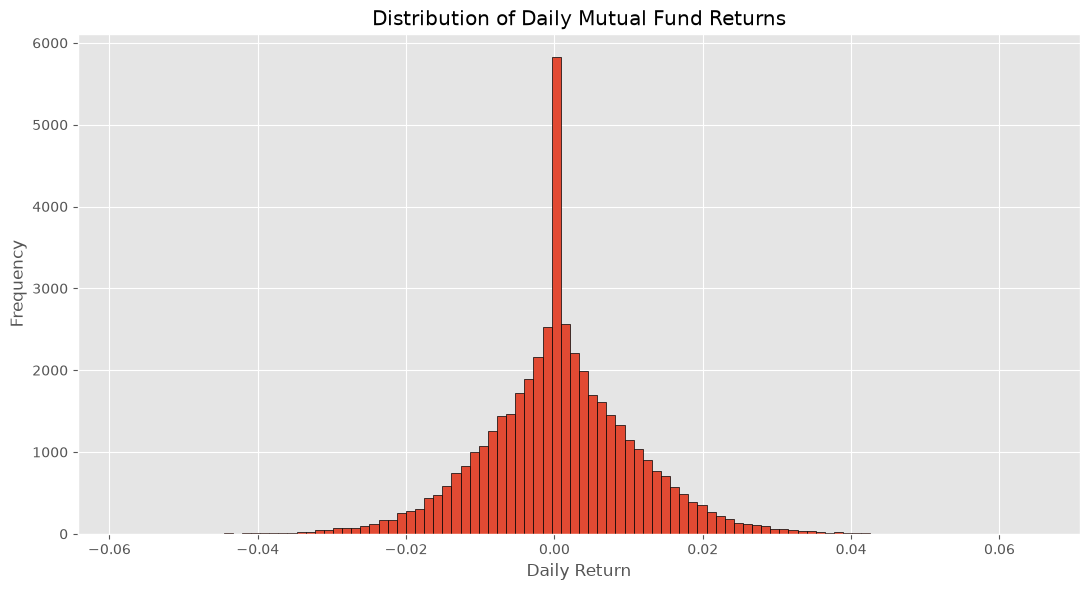

Chart saved successfully.


In [11]:
# ==========================================================
# Daily Return Distribution
# ==========================================================

plt.figure(figsize=(11,6))

plt.hist(
    nav_df["daily_return"].dropna(),
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Daily Mutual Fund Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully.")

In [12]:
# ==========================================================
# Validate Daily Returns
# ==========================================================

print("Minimum Return :", nav_df["daily_return"].min())
print("Maximum Return :", nav_df["daily_return"].max())
print("Mean Return    :", nav_df["daily_return"].mean())
print("Median Return  :", nav_df["daily_return"].median())

Minimum Return : -0.058102013949189124
Maximum Return : 0.06471309359097144
Mean Return    : 0.0006310517590547711
Median Return  : 0.0003402087746056104


In [13]:
# ==========================================================
# CAGR (1Y, 3Y, 5Y)
# ==========================================================

from pandas.tseries.offsets import DateOffset

latest_date = nav_df["date"].max()

cagr_results = []

for amfi_code, fund in nav_df.groupby("amfi_code"):

    fund = fund.sort_values("date")

    latest_nav = fund.iloc[-1]["nav"]

    row = {
        "amfi_code": amfi_code,
        "scheme_name": fund.iloc[0]["scheme_name"]
    }

    for years in [1, 3, 5]:

        target_date = latest_date - DateOffset(years=years)

        historical = fund[fund["date"] <= target_date]

        if historical.empty:
            row[f"CAGR_{years}Y"] = np.nan
            continue

        start_nav = historical.iloc[-1]["nav"]

        cagr = (latest_nav / start_nav) ** (1 / years) - 1

        row[f"CAGR_{years}Y"] = cagr

    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)

In [14]:
# Convert CAGR to percentage

for col in ["CAGR_1Y", "CAGR_3Y", "CAGR_5Y"]:
    cagr_df[col] = (cagr_df[col] * 100).round(2)

cagr_df = cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
).reset_index(drop=True)

cagr_df.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119094,Axis Midcap Fund - Regular - Growth,22.26,35.11,NaN
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,NaN
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,NaN
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.23,32.44,NaN
4,120505,ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,NaN
5,119551,SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,NaN
6,120843,Kotak Flexicap Fund - Regular - Growth,26.66,29.58,NaN
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,NaN
8,101206,ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,NaN
9,149324,DSP Small Cap Fund - Regular - Growth,65.14,27.00,NaN


In [15]:
# ==========================================================
# Save CAGR Report
# ==========================================================

cagr_df.to_csv(
    REPORT_DIR / "cagr_comparison.csv",
    index=False
)

print("Report Saved Successfully")

print(REPORT_DIR / "cagr_comparison.csv")

Report Saved Successfully
c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\outputs\reports\cagr_comparison.csv


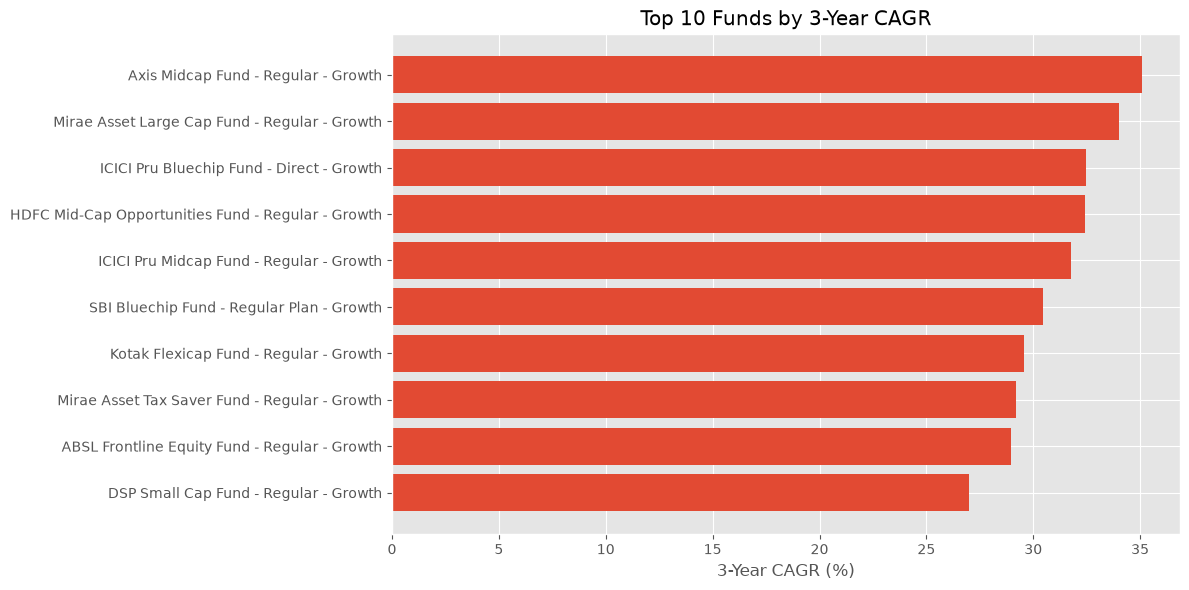

In [16]:
# ==========================================================
# Top 10 Funds by 3-Year CAGR
# ==========================================================

plt.figure(figsize=(12,6))

top10 = cagr_df.head(10)

plt.barh(
    top10["scheme_name"],
    top10["CAGR_3Y"]
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("3-Year CAGR (%)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    CHART_DIR / "top10_cagr_3year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
# ==========================================================
# Sharpe Ratio
# ==========================================================

RISK_FREE_RATE = 0.065  # 6.5%

sharpe_results = []

for amfi_code, fund in nav_df.groupby("amfi_code"):

    returns = fund["daily_return"].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    if annual_volatility == 0:
        sharpe = np.nan
    else:
        sharpe = (annual_return - RISK_FREE_RATE) / annual_volatility

    sharpe_results.append({
        "amfi_code": amfi_code,
        "scheme_name": fund.iloc[0]["scheme_name"],
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

In [18]:
# ==========================================================
# Rank Funds by Sharpe Ratio
# ==========================================================

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)

sharpe_df.head(10)

,amfi_code,scheme_name,annual_return,annual_volatility,sharpe_ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.141937,1.448291,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.272602,0.158870,1.306744,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.176740,1.234930,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.137414,1.208267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.192909,1.180101,5
5,149323,DSP Midcap Fund - Regular - Growth,0.265908,0.177462,1.132122,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.189367,1.093699,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.141484,1.081659,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.145682,1.027213,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.143638,1.026524,10


In [19]:
# ==========================================================
# Export Sharpe Ratio Report
# ==========================================================

sharpe_df.to_csv(
    REPORT_DIR / "sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio report exported successfully.")

Sharpe Ratio report exported successfully.


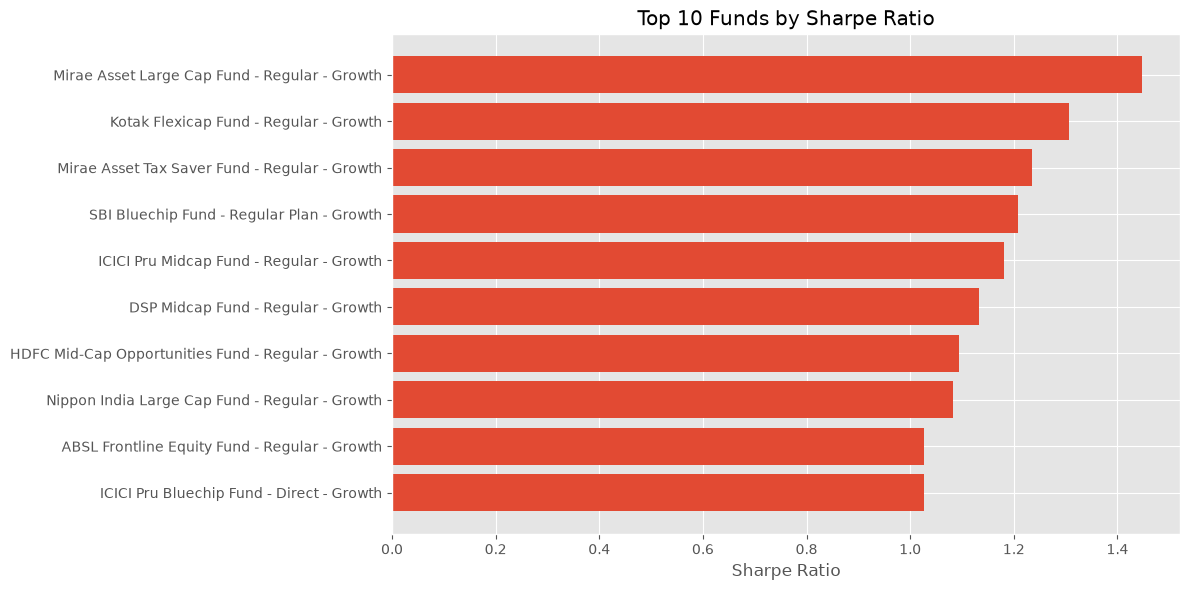

In [20]:
# ==========================================================
# Top 10 Funds by Sharpe Ratio
# ==========================================================

top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["sharpe_ratio"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "top10_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ==========================================================
# Sortino Ratio
# ==========================================================

sortino_results = []

for amfi_code, fund in nav_df.groupby("amfi_code"):

    returns = fund["daily_return"].dropna()

    if len(returns) < 30:
        continue

    annual_return = returns.mean() * 252

    # Only negative returns
    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_deviation = np.nan
    else:
        downside_deviation = downside_returns.std() * np.sqrt(252)

    if pd.isna(downside_deviation) or downside_deviation == 0:
        sortino = np.nan
    else:
        sortino = (annual_return - RISK_FREE_RATE) / downside_deviation

    sortino_results.append({
        "amfi_code": amfi_code,
        "scheme_name": fund.iloc[0]["scheme_name"],
        "annual_return": annual_return,
        "downside_deviation": downside_deviation,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

print("Sortino Ratio calculated successfully.")

Sortino Ratio calculated successfully.


In [22]:
# ==========================================================
# Rank Funds by Sortino Ratio
# ==========================================================

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df["Rank"] = range(1, len(sortino_df) + 1)

sortino_df.head(10)

,amfi_code,scheme_name,annual_return,downside_deviation,sortino_ratio,Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.270566,0.086168,2.385644,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.272602,0.087806,2.364320,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.283262,0.101663,2.146914,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.231033,0.077576,2.140267,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292653,0.112180,2.029353,5
5,149323,DSP Midcap Fund - Regular - Growth,0.265908,0.107145,1.875101,6
6,118632,Nippon India Large Cap Fund - Regular - Growth,0.218037,0.082717,1.850133,7
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.272111,0.113229,1.829134,8
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.212448,0.081675,1.805294,9
9,101206,ABSL Frontline Equity Fund - Regular - Growth,0.214647,0.083157,1.799563,10


In [23]:
# ==========================================================
# Export Sortino Report
# ==========================================================

sortino_df.to_csv(
    REPORT_DIR / "sortino_ratio.csv",
    index=False
)

print("Sortino Ratio report exported successfully.")

Sortino Ratio report exported successfully.


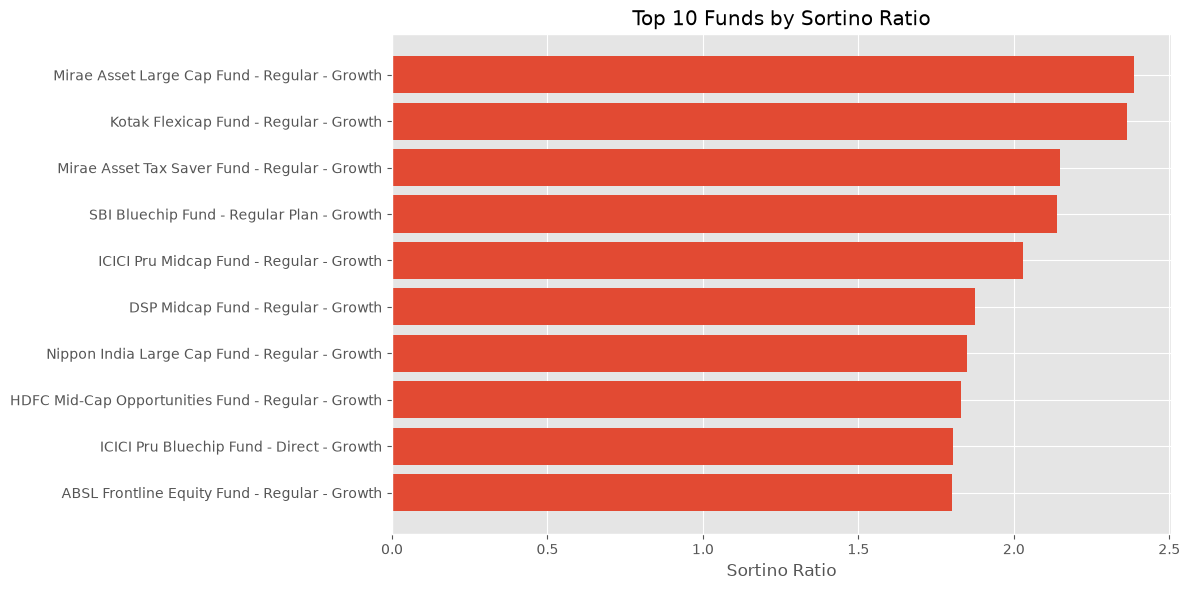

In [24]:
# ==========================================================
# Top 10 Funds by Sortino Ratio
# ==========================================================

top10 = sortino_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["sortino_ratio"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "top10_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# ==========================================================
# Benchmark Daily Returns (NIFTY 100)
# ==========================================================

nifty100_df = (
    benchmark_df[benchmark_df["index_name"] == "NIFTY100"]
    .copy()
)

nifty100_df = nifty100_df.sort_values("date")

nifty100_df["benchmark_return"] = (
    nifty100_df["close_value"]
    .pct_change()
)

nifty100_df = nifty100_df[
    ["date", "benchmark_return"]
].dropna()

print(nifty100_df.head())

           date  benchmark_return
3451 2022-01-04         -0.013540
3452 2022-01-05          0.004003
3453 2022-01-06         -0.002935
3454 2022-01-07          0.006150
3455 2022-01-10         -0.008351


In [26]:
# ==========================================================
# Alpha & Beta using OLS Regression
# ==========================================================

alpha_beta_results = []

for amfi_code, fund in nav_df.groupby("amfi_code"):

    returns = fund[
        ["date", "daily_return", "scheme_name"]
    ].dropna()

    merged = returns.merge(
        nifty100_df,
        on="date",
        how="inner"
    )

    # Skip if insufficient overlap
    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "scheme_name": merged.iloc[0]["scheme_name"],
        "beta": regression.slope,
        "daily_alpha": regression.intercept,
        "annual_alpha": regression.intercept * 252,
        "r_squared": regression.rvalue ** 2,
        "p_value": regression.pvalue
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print(alpha_beta_df.head())

   amfi_code                                        scheme_name      beta  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth -0.058268   
1     100025       HDFC Short Term Debt Fund - Regular - Growth  0.001158   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.005104   
3     101206      ABSL Frontline Equity Fund - Regular - Growth  0.021086   
4     101207             ABSL Small Cap Fund - Regular - Growth -0.065289   

   daily_alpha  annual_alpha  r_squared   p_value  
0     0.000149      0.037476   0.002665  0.080264  
1     0.000170      0.042818   0.000015  0.897012  
2     0.001079      0.271954   0.000012  0.906369  
3     0.000849      0.213998   0.000348  0.527551  
4     0.000432      0.108971   0.001064  0.269234  


In [27]:
# ==========================================================
# Rank by Annual Alpha
# ==========================================================

alpha_beta_df = (
    alpha_beta_df
    .sort_values(
        "annual_alpha",
        ascending=False
    )
    .reset_index(drop=True)
)

alpha_beta_df["Rank"] = range(
    1,
    len(alpha_beta_df) + 1
)

alpha_beta_df.head(10)

,amfi_code,scheme_name,beta,daily_alpha,annual_alpha,r_squared,p_value,Rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.023196,0.001204,0.303370,1.414258e-04,0.687179,1
1,149324,DSP Small Cap Fund - Regular - Growth,0.011455,0.001193,0.300579,3.532991e-05,0.840494,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.000549,0.001161,0.292636,1.345534e-07,0.990090,3
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.018134,0.001122,0.282704,1.748889e-04,0.654295,4
4,120843,Kotak Flexicap Fund - Regular - Growth,-0.022830,0.001085,0.273305,3.430543e-04,0.530528,5
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.005104,0.001079,0.271954,1.206652e-05,0.906369,6
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.023684,0.001071,0.269838,4.625437e-04,0.466427,7
7,149323,DSP Midcap Fund - Regular - Growth,-0.002523,0.001055,0.265986,3.357978e-06,0.950525,8
8,119094,Axis Midcap Fund - Regular - Growth,-0.066265,0.001035,0.260767,1.936879e-03,0.135988,9
9,119551,SBI Bluechip Fund - Regular Plan - Growth,-0.031751,0.000921,0.232010,8.869789e-04,0.313143,10


In [28]:
# ==========================================================
# Export Alpha Beta Report
# ==========================================================

alpha_beta_df.to_csv(
    REPORT_DIR / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv exported successfully.")

alpha_beta.csv exported successfully.


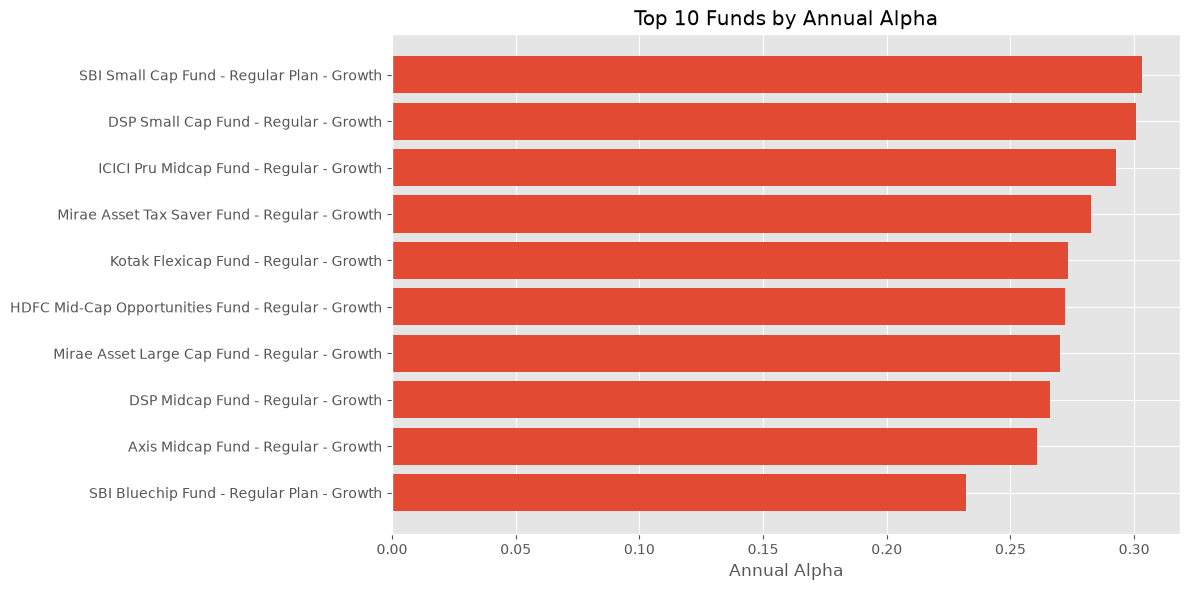

In [29]:
# ==========================================================
# Top 10 Funds by Annual Alpha
# ==========================================================

top10 = alpha_beta_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["annual_alpha"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds by Annual Alpha")

plt.xlabel("Annual Alpha")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "top10_alpha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
alpha_beta_df.describe()

,amfi_code,beta,daily_alpha,annual_alpha,r_squared,p_value,Rank
count,40.000000,40.000000,40.000000,40.000000,4.000000e+01,40.000000,40.000000
mean,120247.000000,-0.001958,0.000631,0.159085,6.087700e-04,0.545393,20.500000
std,14534.998667,0.035194,0.000347,0.087528,7.265363e-04,0.280488,11.690452
min,100016.000000,-0.066951,0.000115,0.028969,1.345534e-07,0.073339,1.000000
25%,118632.750000,-0.023937,0.000272,0.068612,5.495723e-05,0.275811,10.750000
50%,119551.500000,-0.000067,0.000644,0.162326,3.455513e-04,0.529040,20.500000
75%,120842.250000,0.017026,0.000880,0.221723,1.035467e-03,0.802038,30.250000
max,149324.000000,0.103497,0.001204,0.303370,2.793007e-03,0.990090,40.000000


In [31]:
benchmark_df["index_name"].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [32]:
benchmark_df["index_name"].value_counts()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64

In [33]:
merged = (
    nav_df[nav_df["amfi_code"] == nav_df["amfi_code"].iloc[0]][
        ["date", "daily_return"]
    ]
    .dropna()
    .merge(
        nifty100_df,
        on="date",
        how="inner"
    )
)

print(merged.shape)
print(merged.head())
print(merged[["daily_return", "benchmark_return"]].corr())

(1149, 3)
        date  daily_return  benchmark_return
0 2022-01-04     -0.010306         -0.013540
1 2022-01-05      0.012865          0.004003
2 2022-01-06     -0.011377         -0.002935
3 2022-01-07     -0.001210          0.006150
4 2022-01-10     -0.008639         -0.008351
                  daily_return  benchmark_return
daily_return          1.000000         -0.051624
benchmark_return     -0.051624          1.000000


In [34]:
# ==========================================================
# Maximum Drawdown
# ==========================================================

drawdown_results = []

for amfi_code, fund in nav_df.groupby("amfi_code"):

    fund = fund.sort_values("date").copy()

    fund["running_max"] = fund["nav"].cummax()

    fund["drawdown"] = (
        fund["nav"] / fund["running_max"]
    ) - 1

    # Worst drawdown
    worst_idx = fund["drawdown"].idxmin()

    worst_row = fund.loc[worst_idx]

    trough_date = worst_row["date"]
    max_drawdown = worst_row["drawdown"]

    # Peak before trough
    peak_rows = fund.loc[:worst_idx]

    peak_idx = peak_rows["nav"].idxmax()

    peak_date = fund.loc[peak_idx, "date"]

    drawdown_results.append({

        "amfi_code": amfi_code,

        "scheme_name": fund.iloc[0]["scheme_name"],

        "max_drawdown": max_drawdown,

        "peak_date": peak_date,

        "trough_date": trough_date

    })

max_drawdown_df = pd.DataFrame(drawdown_results)

print(max_drawdown_df.head())

   amfi_code                                        scheme_name  max_drawdown  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth     -0.247344   
1     100025       HDFC Short Term Debt Fund - Regular - Growth     -0.043083   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -0.162172   
3     101206      ABSL Frontline Equity Fund - Regular - Growth     -0.112916   
4     101207             ABSL Small Cap Fund - Regular - Growth     -0.354469   

   peak_date trough_date  
0 2022-03-30  2022-09-15  
1 2023-05-23  2023-07-28  
2 2022-03-11  2022-05-12  
3 2023-04-24  2023-07-05  
4 2024-11-21  2026-05-11  


In [35]:
# ==========================================================
# Rank by Maximum Drawdown
# ==========================================================

max_drawdown_df = max_drawdown_df.sort_values(
    "max_drawdown",
    ascending=False
).reset_index(drop=True)

max_drawdown_df["Rank"] = range(
    1,
    len(max_drawdown_df)+1
)

max_drawdown_df.head(10)

,amfi_code,scheme_name,max_drawdown,peak_date,trough_date,Rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-16,2025-10-20,1
1,120844,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-12,2024-04-30,2
2,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-05,2023-09-12,3
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28,4
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2024-09-16,2025-04-01,5
5,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2023-02-09,2024-02-09,6
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-02-03,2022-03-29,7
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-07-11,2023-10-20,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05,9
9,118635,Nippon India ETF Nifty 50 BeES,-0.116506,2022-01-03,2022-06-09,10


In [36]:
# ==========================================================
# Export Maximum Drawdown Report
# ==========================================================

max_drawdown_df.to_csv(
    REPORT_DIR / "max_drawdown.csv",
    index=False
)

print("Maximum Drawdown report exported successfully.")

Maximum Drawdown report exported successfully.


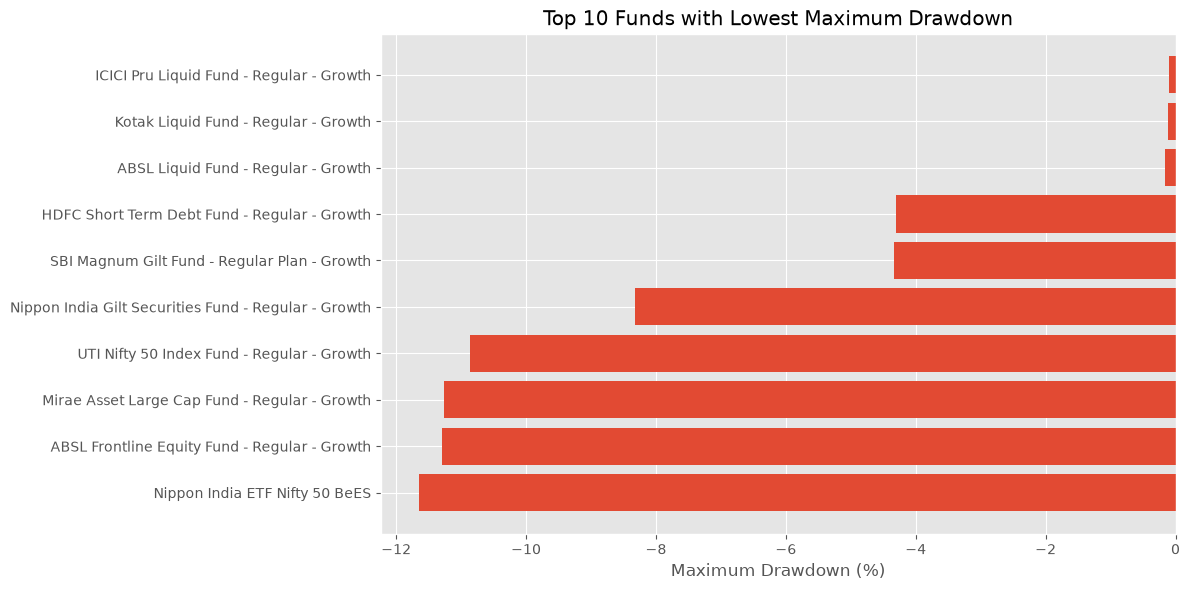

In [37]:
# ==========================================================
# Top 10 Funds by Maximum Drawdown
# ==========================================================

top10 = max_drawdown_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["max_drawdown"] * 100
)

plt.gca().invert_yaxis()

plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.xlabel("Maximum Drawdown (%)")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "top10_max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# ==========================================================
# Maximum Drawdown Summary
# ==========================================================

print(
    max_drawdown_df["max_drawdown"].describe()
)

count    40.000000
mean     -0.178729
std       0.112686
min      -0.525742
25%      -0.215927
50%      -0.163070
75%      -0.117653
max      -0.000977
Name: max_drawdown, dtype: float64


In [39]:
# ==========================================================
# Prepare Rankings for Composite Score
# ==========================================================

# CAGR Rank (higher CAGR is better)
cagr_rank = cagr_df[["amfi_code", "CAGR_3Y"]].copy()
cagr_rank["cagr_rank"] = cagr_rank["CAGR_3Y"].rank(
    ascending=False,
    method="dense"
)

# Sharpe Rank
sharpe_rank = sharpe_df[["amfi_code", "sharpe_ratio"]].copy()
sharpe_rank["sharpe_rank"] = sharpe_rank["sharpe_ratio"].rank(
    ascending=False,
    method="dense"
)

# Alpha Rank
alpha_rank = alpha_beta_df[["amfi_code", "annual_alpha"]].copy()
alpha_rank["alpha_rank"] = alpha_rank["annual_alpha"].rank(
    ascending=False,
    method="dense"
)

# Expense Ratio Rank (lower is better)
expense_rank = funds_df[
    ["amfi_code", "scheme_name", "expense_ratio_pct"]
].copy()

expense_rank["expense_rank"] = expense_rank["expense_ratio_pct"].rank(
    ascending=True,
    method="dense"
)

# Drawdown Rank (less negative is better)
drawdown_rank = max_drawdown_df[
    ["amfi_code", "max_drawdown"]
].copy()

drawdown_rank["drawdown_rank"] = drawdown_rank["max_drawdown"].rank(
    ascending=False,
    method="dense"
)

In [40]:
# ==========================================================
# Merge All Rankings
# ==========================================================

scorecard_df = expense_rank.merge(
    cagr_rank[["amfi_code", "cagr_rank"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    sharpe_rank[["amfi_code", "sharpe_rank"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    alpha_rank[["amfi_code", "alpha_rank"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    drawdown_rank[["amfi_code", "drawdown_rank"]],
    on="amfi_code"
)

scorecard_df.head()

,amfi_code,scheme_name,expense_ratio_pct,expense_rank,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,24.0,6.0,4.0,10.0,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,4.0,23.0,12.0,15.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,18.0,12.0,14.0,1.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,5.0,38.0,32.0,36.0,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,8.0,32.0,37.0,34.0,5.0


In [41]:
# ==========================================================
# Composite Fund Score (0-100)
# ==========================================================

n = len(scorecard_df)

# Convert ranks to normalized scores (higher is better)
for col in [
    "cagr_rank",
    "sharpe_rank",
    "alpha_rank",
    "expense_rank",
    "drawdown_rank"
]:
    scorecard_df[col + "_score"] = (
        (n - scorecard_df[col]) / (n - 1)
    ) * 100

scorecard_df["Fund_Score"] = (

      scorecard_df["cagr_rank_score"] * 0.30
    + scorecard_df["sharpe_rank_score"] * 0.25
    + scorecard_df["alpha_rank_score"] * 0.20
    + scorecard_df["expense_rank_score"] * 0.15
    + scorecard_df["drawdown_rank_score"] * 0.10

)

scorecard_df["Fund_Score"] = scorecard_df["Fund_Score"].round(2)

In [42]:
# ==========================================================
# Final Ranking
# ==========================================================

scorecard_df = scorecard_df.sort_values(
    "Fund_Score",
    ascending=False
).reset_index(drop=True)

scorecard_df["Overall_Rank"] = range(
    1,
    len(scorecard_df) + 1
)

scorecard_df.head(10)

,amfi_code,scheme_name,expense_ratio_pct,expense_rank,cagr_rank,sharpe_rank,alpha_rank,drawdown_rank,cagr_rank_score,sharpe_rank_score,alpha_rank_score,expense_rank_score,drawdown_rank_score,Fund_Score,Overall_Rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,20.0,2.0,1.0,7.0,8.0,97.435897,100.000000,84.615385,51.282051,82.051282,87.05,1
1,120843,Kotak Flexicap Fund - Regular - Growth,1.45,19.0,7.0,2.0,5.0,13.0,84.615385,97.435897,89.743590,53.846154,69.230769,82.69,2
2,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,14.0,5.0,5.0,3.0,25.0,89.743590,89.743590,94.871795,66.666667,38.461538,82.18,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,15.0,4.0,7.0,6.0,20.0,92.307692,84.615385,87.179487,64.102564,51.282051,81.03,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,11.0,3.0,10.0,13.0,12.0,94.871795,76.923077,69.230769,74.358974,71.794872,79.87,5
5,119094,Axis Midcap Fund - Regular - Growth,1.38,15.0,1.0,11.0,9.0,28.0,100.000000,74.358974,79.487179,64.102564,30.769231,77.18,6
6,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,24.0,6.0,4.0,10.0,17.0,87.179487,92.307692,76.923077,41.025641,58.974359,76.67,7
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,29.0,8.0,3.0,4.0,21.0,82.051282,94.871795,92.307692,28.205128,48.717949,75.90,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,1.60,29.0,9.0,9.0,12.0,9.0,79.487179,79.487179,71.794872,28.205128,79.487179,70.26,9
9,149323,DSP Midcap Fund - Regular - Growth,1.61,30.0,11.0,6.0,8.0,22.0,74.358974,87.179487,82.051282,25.641026,46.153846,68.97,10


In [43]:
# ==========================================================
# Export Scorecard
# ==========================================================

scorecard_df.to_csv(
    REPORT_DIR / "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard exported successfully.")

Fund Scorecard exported successfully.


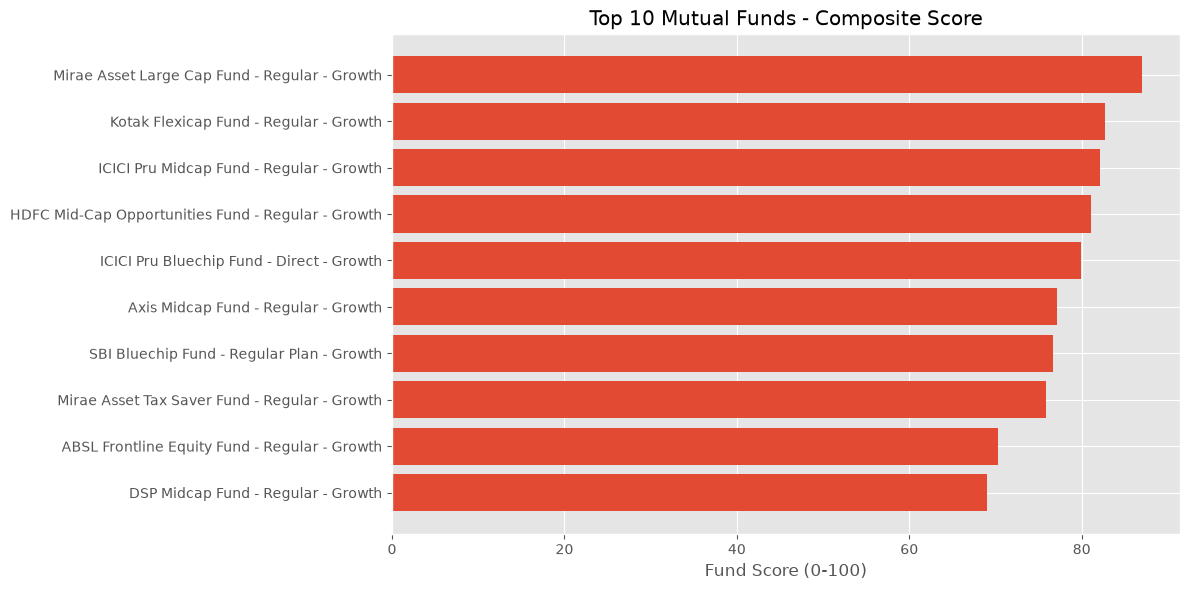

In [44]:
# ==========================================================
# Top 10 Fund Scorecard
# ==========================================================

top10 = scorecard_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Mutual Funds - Composite Score")

plt.xlabel("Fund Score (0-100)")

plt.tight_layout()

plt.savefig(
    CHART_DIR / "fund_scorecard_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# ==========================================================
# Top 5 Funds
# ==========================================================

top5_codes = scorecard_df.head(5)["amfi_code"].tolist()

top5_names = (
    scorecard_df
    .head(5)[["amfi_code","scheme_name"]]
)

top5_names

,amfi_code,scheme_name
0,148567,Mirae Asset Large Cap Fund - Regular - Growth
1,120843,Kotak Flexicap Fund - Regular - Growth
2,120505,ICICI Pru Midcap Fund - Regular - Growth
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,ICICI Pru Bluechip Fund - Direct - Growth


In [46]:
# ==========================================================
# Prepare Benchmark Data
# ==========================================================

benchmarks = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50","NIFTY100"])
].copy()

benchmarks = benchmarks.sort_values(
    ["index_name","date"]
)

benchmarks["normalized"] = (
    benchmarks.groupby("index_name")["close_value"]
    .transform(lambda x: x/x.iloc[0]*100)
)

benchmarks.head()

,date,index_name,close_value,normalized
3450,2022-01-03,NIFTY100,17778.24,100.000000
3451,2022-01-04,NIFTY100,17537.52,98.645985
3452,2022-01-05,NIFTY100,17607.73,99.040906
3453,2022-01-06,NIFTY100,17556.05,98.750214
3454,2022-01-07,NIFTY100,17664.02,99.357529


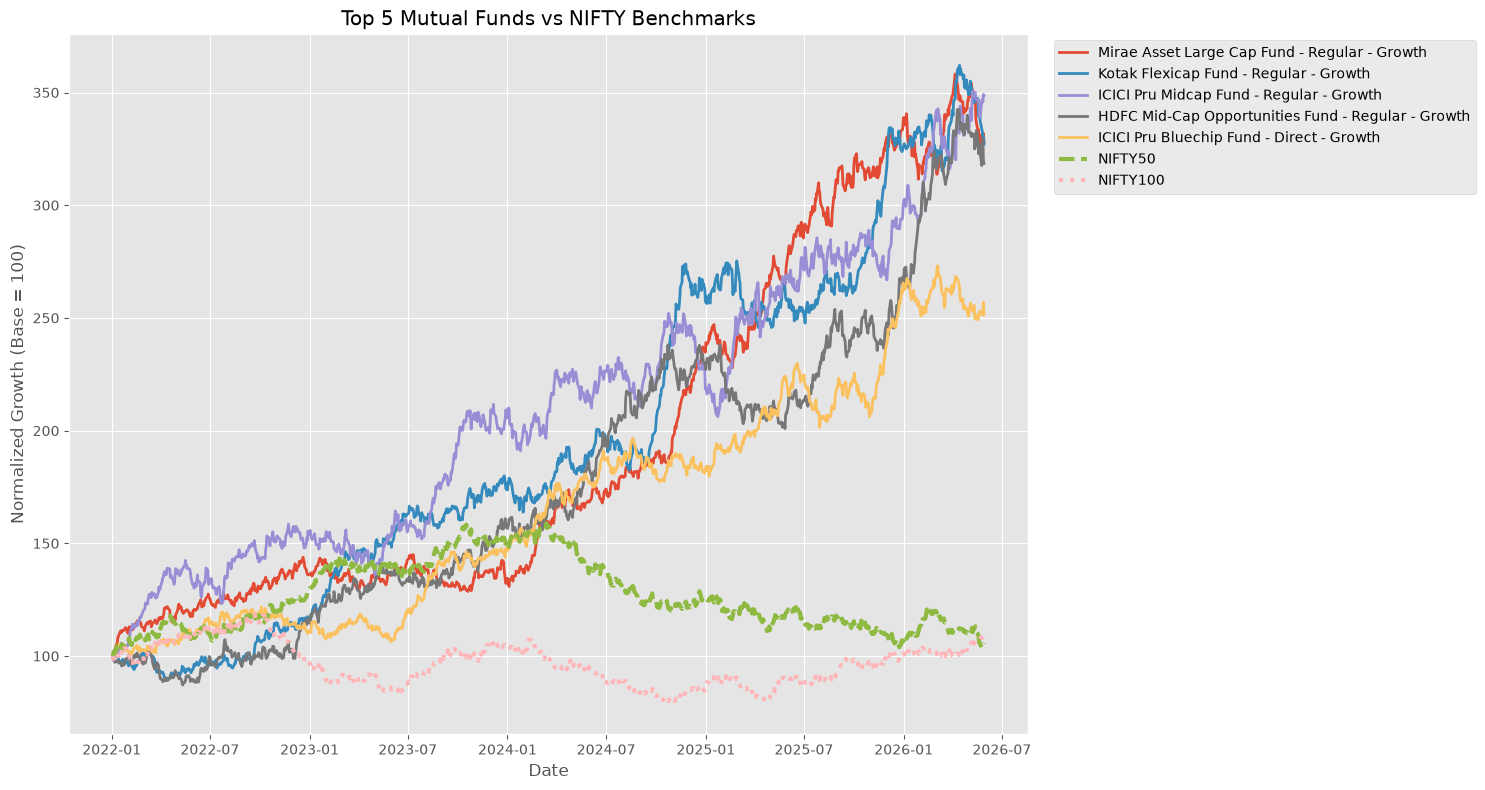

In [47]:
# ==========================================================
# Benchmark Comparison
# ==========================================================

plt.figure(figsize=(15,8))

# Plot Top 5 Funds
for code in top5_codes:

    temp = nav_df[
        nav_df["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        linewidth=2,
        label=temp["scheme_name"].iloc[0]
    )

# Plot NIFTY50
temp = benchmarks[
    benchmarks["index_name"]=="NIFTY50"
]

plt.plot(
    temp["date"],
    temp["normalized"],
    linestyle="--",
    linewidth=3,
    label="NIFTY50"
)

# Plot NIFTY100
temp = benchmarks[
    benchmarks["index_name"]=="NIFTY100"
]

plt.plot(
    temp["date"],
    temp["normalized"],
    linestyle=":",
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Mutual Funds vs NIFTY Benchmarks")

plt.xlabel("Date")

plt.ylabel("Normalized Growth (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR /
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# ==========================================================
# Tracking Error
# ==========================================================

nifty100_returns = (
    benchmark_df[
        benchmark_df["index_name"]=="NIFTY100"
    ][["date","close_value"]]
    .copy()
)

nifty100_returns["benchmark_return"] = (
    nifty100_returns["close_value"]
    .pct_change()
)

tracking_error = []

for code in top5_codes:

    fund = nav_df[
        nav_df["amfi_code"]==code
    ][["date","daily_return","scheme_name"]].dropna()

    merged = fund.merge(
        nifty100_returns[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    te = (
        (merged["daily_return"]-
         merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append({

        "amfi_code":code,

        "scheme_name":
        merged.iloc[0]["scheme_name"],

        "tracking_error":te

    })

tracking_error_df = pd.DataFrame(
    tracking_error
)

tracking_error_df

,amfi_code,scheme_name,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.189664
1,120843,Kotak Flexicap Fund - Regular - Growth,0.206425
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.191587


In [49]:
# ==========================================================
# Export Tracking Error
# ==========================================================

tracking_error_df.to_csv(
    REPORT_DIR /
    "tracking_error.csv",
    index=False
)

print("Tracking Error exported successfully.")

Tracking Error exported successfully.


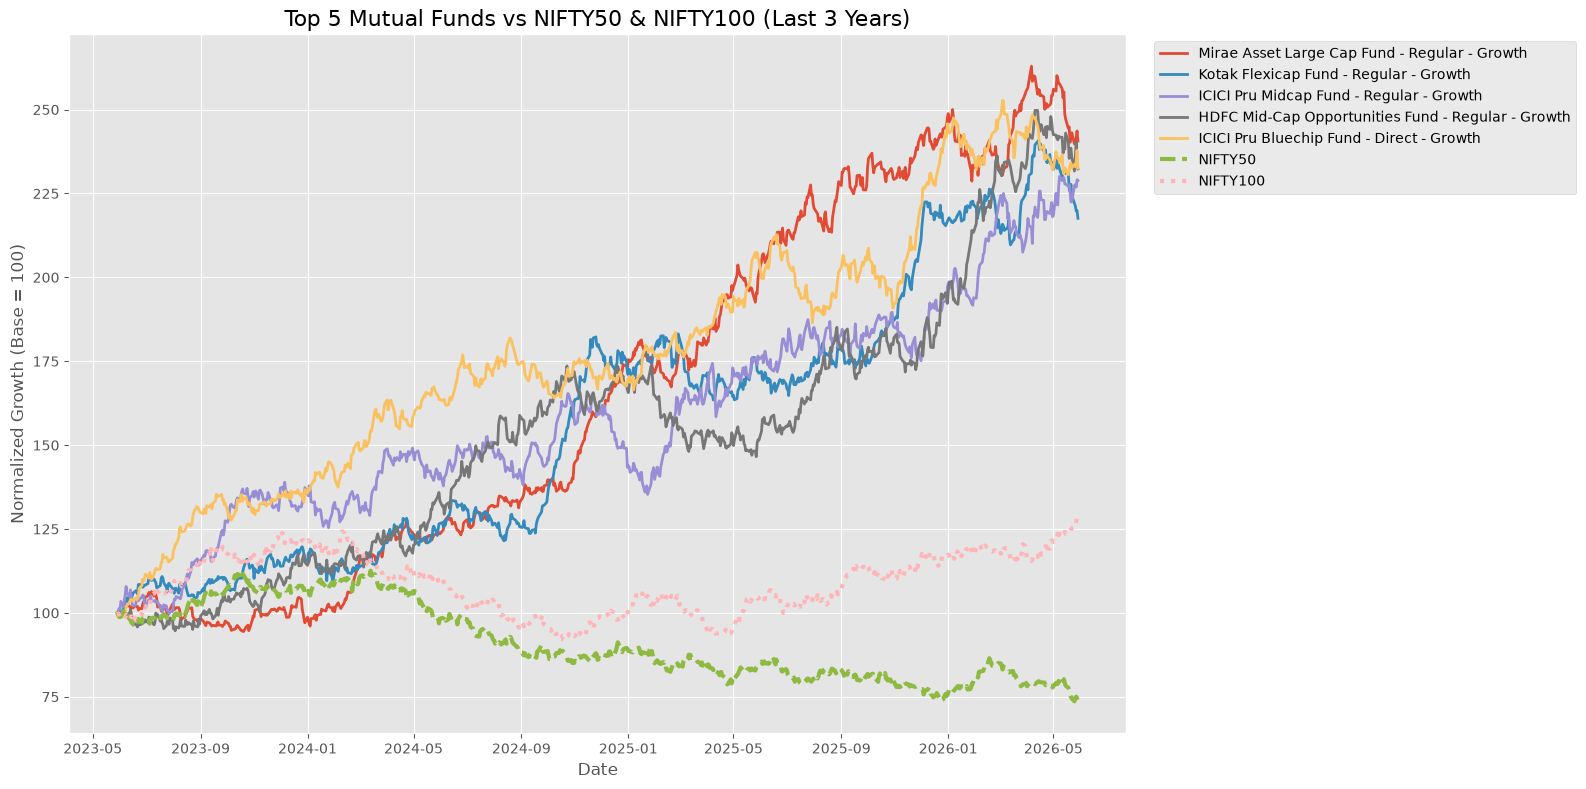

Benchmark comparison chart saved successfully.


In [50]:
# ==========================================================
# Benchmark Comparison (Last 3 Years)
# ==========================================================

from pandas.tseries.offsets import DateOffset

latest_date = nav_df["date"].max()
start_date = latest_date - DateOffset(years=3)

plt.figure(figsize=(16,8))

# ----------------------------------------------------------
# Plot Top 5 Funds
# ----------------------------------------------------------

for code in top5_codes:

    temp = nav_df[
        (nav_df["amfi_code"] == code) &
        (nav_df["date"] >= start_date)
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"] /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        linewidth=2,
        label=temp["scheme_name"].iloc[0]
    )

# ----------------------------------------------------------
# Plot Benchmarks
# ----------------------------------------------------------

for benchmark_name, style in [
    ("NIFTY50", "--"),
    ("NIFTY100", ":")
]:

    temp = benchmark_df[
        (benchmark_df["index_name"] == benchmark_name) &
        (benchmark_df["date"] >= start_date)
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["close_value"] /
        temp["close_value"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        linestyle=style,
        linewidth=3,
        label=benchmark_name
    )

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (Last 3 Years)", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Benchmark comparison chart saved successfully.")

# Day 5 Performance Analytics Summary

The following performance metrics were successfully computed for all available mutual fund schemes:

- Daily Return Distribution
- CAGR (1-Year, 3-Year, 5-Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta (OLS Regression using NIFTY100)
- Maximum Drawdown
- Composite Fund Scorecard (0–100)
- Benchmark Comparison (Top 5 Funds vs NIFTY50 & NIFTY100)
- Tracking Error

### Deliverables Generated

- cagr_comparison.csv
- sharpe_ratio.csv
- sortino_ratio.csv
- alpha_beta.csv
- max_drawdown.csv
- fund_scorecard.csv
- tracking_error.csv

### Charts Generated

- Daily Return Distribution
- Top 10 CAGR
- Top 10 Sharpe Ratio
- Top 10 Sortino Ratio
- Top 10 Alpha
- Top 10 Maximum Drawdown
- Top 10 Fund Scorecard
- Benchmark Comparison

In [51]:
from pathlib import Path

for f in Path("data/processed").glob("*.csv"):
    print(f.name)

In [53]:
from pathlib import Path

processed_path = Path("data/processed")

files = list(processed_path.glob("*.csv"))

for f in files:
    print(f.name)

In [54]:
import os
print(os.getcwd())

c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics\notebooks


In [55]:
from pathlib import Path

print(Path("data").exists())
print(Path("data/processed").exists())

False
False


In [56]:
import os

os.chdir("..")

print("New Working Directory:", os.getcwd())

New Working Directory: c:\College notes\Internship\Bluestock Finetech Internship\MutualFundAnalytics


In [57]:
from pathlib import Path

print(Path("data").exists())
print(Path("data/processed").exists())

True
True


In [58]:
from pathlib import Path

processed_path = Path("data/processed")

files = list(processed_path.glob("*.csv"))

for f in files:
    print(f.name)

aum_by_fund_house.csv
benchmark_indices.csv
category_inflows.csv
fund_master.csv
industry_folio_count.csv
investor_transactions.csv
monthly_sip_inflows.csv
nav_history.csv
portfolio_holdings.csv
scheme_performance.csv
